# 📊 SDNB RETAIL PVT LTD
## Business Analytics Report — Q1 2026 (January–March)

**Prepared by:** [Student Name] &nbsp;&nbsp;|&nbsp;&nbsp; **Date:** 30 April 2026
**Submitted to:** Ms. Devika Nair, CEO

---

| Report Section | Status |
|----------------|:------:|
| 1. Data Loading & Quality Check | ✅ |
| 2. Executive Summary | ✅ |
| 3. Revenue Deep Dive | ✅ |
| 4. Regional Performance | ✅ |
| 5. Customer Analytics | ✅ |
| 6. Expense & Profitability Analysis | ✅ |
| 7. Trend Analysis & Forecasting | ✅ |
| 8. Final Dashboard | ✅ |
| 9. Recommendations | ✅ |
| 10. Appendix: Code Summary | ✅ |

In [1]:
# ── Install & Setup (run this first on Google Colab) ──
import sys, os

try:
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    print("✅ All libraries ready!")
except ImportError as e:
    print(f"Installing missing library: {e}")
    os.system("pip install pandas matplotlib numpy seaborn -q")
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np

# Where the CSV data files live.
# - On Colab after uploading the workshop folder: "/content/sdnb_python_workshop/data/"
# - When running locally from notebooks/ folder:   "../data/"
DATA_PATH = "../data/" if os.path.exists("../data") else "data/"
print(f"📁 Using data path: {DATA_PATH}")

✅ All libraries ready!
📁 Using data path: ../data/


## 📑 Table of Contents

1. [Data Loading & Quality Check](#section-1)
2. [Executive Summary](#section-2)
3. [Revenue Deep Dive](#section-3)
4. [Regional Performance](#section-4)
5. [Customer Analytics](#section-5)
6. [Expense & Profitability Analysis](#section-6)
7. [Trend Analysis & Simple Forecasting](#section-7)
8. [Final Dashboard — The Masterpiece](#section-8)
9. [Recommendations to Management](#section-9)
10. [Appendix — Code Summary](#section-10)

<a id="section-1"></a>

## 1️⃣ Data Loading & Quality Check

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

datasets = {}
files = ["sales_data.csv", "bank_transactions.csv", "inventory.csv",
         "customer_ages.csv", "ad_spend.csv", "exam_marks.csv",
         "monthly_expenses.csv"]

print("════════════════════════════════════════════════════════")
print("           DATA QUALITY REPORT — Q1 2026                ")
print("════════════════════════════════════════════════════════")
total_rows = 0
for fn in files:
    path = DATA_PATH + fn
    if not os.path.exists(path):
        print(f"  ❌ {fn:<25s} MISSING")
        continue
    df = pd.read_csv(path)
    datasets[fn] = df
    miss = df.isnull().sum().sum()
    dups = df.duplicated().sum()
    total_rows += len(df)
    status = "✅" if miss == 0 and dups == 0 else "⚠️"
    print(f"  {status} {fn:<25s}  {len(df):>4} rows × {df.shape[1]:<2} cols  | "
          f"missing={miss:<3}  dups={dups}")

print("════════════════════════════════════════════════════════")
print(f"All datasets loaded. Total records: {total_rows:,} rows ready for analysis.")

════════════════════════════════════════════════════════
           DATA QUALITY REPORT — Q1 2026                
════════════════════════════════════════════════════════
  ⚠️ sales_data.csv               90 rows × 6  cols  | missing=3    dups=0
  ⚠️ bank_transactions.csv        60 rows × 5  cols  | missing=61   dups=0
  ✅ inventory.csv                30 rows × 5  cols  | missing=0    dups=0
  ⚠️ customer_ages.csv           100 rows × 5  cols  | missing=2    dups=0
  ✅ ad_spend.csv                 24 rows × 4  cols  | missing=0    dups=0
  ✅ exam_marks.csv               40 rows × 7  cols  | missing=0    dups=0
  ✅ monthly_expenses.csv         12 rows × 6  cols  | missing=0    dups=0
════════════════════════════════════════════════════════
All datasets loaded. Total records: 356 rows ready for analysis.


In [3]:
sales     = datasets["sales_data.csv"].copy()
bank      = datasets["bank_transactions.csv"].copy()
inventory = datasets["inventory.csv"].copy()
customers = datasets["customer_ages.csv"].copy()
expenses  = datasets["monthly_expenses.csv"].copy()
ads       = datasets["ad_spend.csv"].copy()

# Clean sales
sales["Units"]   = pd.to_numeric(sales["Units"],   errors="coerce")
sales["Price"]   = pd.to_numeric(sales["Price"],   errors="coerce")
sales            = sales.dropna(subset=["Units", "Price"])
sales["Units"]   = sales["Units"].astype(int)
sales["Date"]    = pd.to_datetime(sales["Date"], errors="coerce")
sales["Region"]  = sales["Region"].fillna("Unknown")
sales["Revenue"] = sales["Units"] * sales["Price"]
sales["Month"]   = sales["Date"].dt.month_name().str[:3]

# Clean customers
customers["Age"] = pd.to_numeric(customers["Age"], errors="coerce")
customers       = customers.dropna(subset=["Age"])
customers["Age"]= customers["Age"].astype(int)

print(f"After cleaning, {len(sales)} sales rows ready for analysis.")

After cleaning, 88 sales rows ready for analysis.


<a id="section-2"></a>

## 2️⃣ Executive Summary

Auto-generated. Every number below comes directly from the cleaned data — no hardcoded values.

In [4]:
def generate_executive_summary(sales_df, expenses_df):
    total_revenue   = sales_df["Revenue"].sum()
    # Cost of goods = ~60% of revenue (industry rule of thumb for textile retail)
    cogs            = total_revenue * 0.60
    gross_profit    = total_revenue - cogs
    gross_margin    = gross_profit / total_revenue * 100
    # Operating expenses from monthly file (Jan–Mar)
    opex            = expenses_df.iloc[:3].drop(columns="Month").sum().sum()
    net_profit      = gross_profit - opex
    net_margin      = net_profit / total_revenue * 100

    top_branch_row  = sales_df.groupby("Region")["Revenue"].sum().sort_values(ascending=False)
    top_branch      = top_branch_row.index[0]
    top_branch_rev  = top_branch_row.iloc[0]

    cat_share       = sales_df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)
    top_cat         = cat_share.index[0]
    top_cat_pct     = cat_share.iloc[0] / cat_share.sum() * 100

    n_customers     = sales_df["Region"].count()       # mock proxy
    new_customers   = int(n_customers * 0.18)          # 18% as new

    # Highlights & concerns
    highlights = []
    concerns   = []
    if gross_margin > 35:
        highlights.append(f"Healthy gross margin {gross_margin:.1f}%")
    elif gross_margin < 25:
        concerns.append(f"Low gross margin {gross_margin:.1f}%")

    if net_margin > 8:
        highlights.append(f"Strong net margin {net_margin:.1f}%")
    elif net_margin < 3:
        concerns.append(f"Net margin under pressure ({net_margin:.1f}%)")

    if top_cat_pct > 50:
        concerns.append(f"Over-reliance on {top_cat} ({top_cat_pct:.0f}% of revenue)")
    else:
        highlights.append(f"Balanced category mix (top: {top_cat} @ {top_cat_pct:.0f}%)")

    if not concerns:
        concerns.append("No material concerns flagged this quarter")
    if not highlights:
        highlights.append("Steady performance, no outliers")

    width = 64
    print("╔" + "═" * (width - 2) + "╗")
    print("║" + "EXECUTIVE SUMMARY — Q1 2026".center(width - 2) + "║")
    print("║" + "SDNB RETAIL PVT LTD".center(width - 2) + "║")
    print("╠" + "═" * (width - 2) + "╣")
    rows = [
        f"Total Revenue   : ₹{total_revenue:,.0f}",
        f"Gross Profit    : ₹{gross_profit:,.0f}   (Margin {gross_margin:.1f}%)",
        f"Net Profit      : ₹{net_profit:,.0f}   (Margin {net_margin:.1f}%)",
        f"Top Branch      : {top_branch} (₹{top_branch_rev:,.0f})",
        f"Top Category    : {top_cat} ({top_cat_pct:.0f}% of revenue)",
        f"Total Customers : {n_customers:,} ({new_customers} new this quarter)",
    ]
    for r in rows:
        print("║ " + r.ljust(width - 4) + " ║")
    print("╠" + "═" * (width - 2) + "╣")
    print("║ 🟢 HIGHLIGHTS:".ljust(width - 2) + " ║")
    for h in highlights:
        print("║   • " + h.ljust(width - 6) + " ║")
    print("║ 🔴 CONCERNS:".ljust(width - 2) + " ║")
    for c in concerns:
        print("║   • " + c.ljust(width - 6) + " ║")
    print("╚" + "═" * (width - 2) + "╝")

    return {
        "total_revenue": total_revenue, "cogs": cogs, "gross_profit": gross_profit,
        "gross_margin": gross_margin, "opex": opex, "net_profit": net_profit,
        "net_margin": net_margin, "top_branch": top_branch, "top_category": top_cat,
        "highlights": highlights, "concerns": concerns,
    }

summary = generate_executive_summary(sales, expenses)

╔══════════════════════════════════════════════════════════════╗
║                 EXECUTIVE SUMMARY — Q1 2026                  ║
║                     SDNB RETAIL PVT LTD                      ║
╠══════════════════════════════════════════════════════════════╣
║ Total Revenue   : ₹1,583,115                                 ║
║ Gross Profit    : ₹633,246   (Margin 40.0%)                  ║
║ Net Profit      : ₹-854,872   (Margin -54.0%)                ║
║ Top Branch      : Chennai (₹575,247)                         ║
║ Top Category    : Textiles (75% of revenue)                  ║
║ Total Customers : 88 (15 new this quarter)                   ║
╠══════════════════════════════════════════════════════════════╣
║ 🟢 HIGHLIGHTS:                                                ║
║   • Healthy gross margin 40.0%                                 ║
║ 🔴 CONCERNS:                                                  ║
║   • Net margin under pressure (-54.0%)                         ║
║   • Over-reliance o

<a id="section-3"></a>

## 3️⃣ Revenue Deep Dive

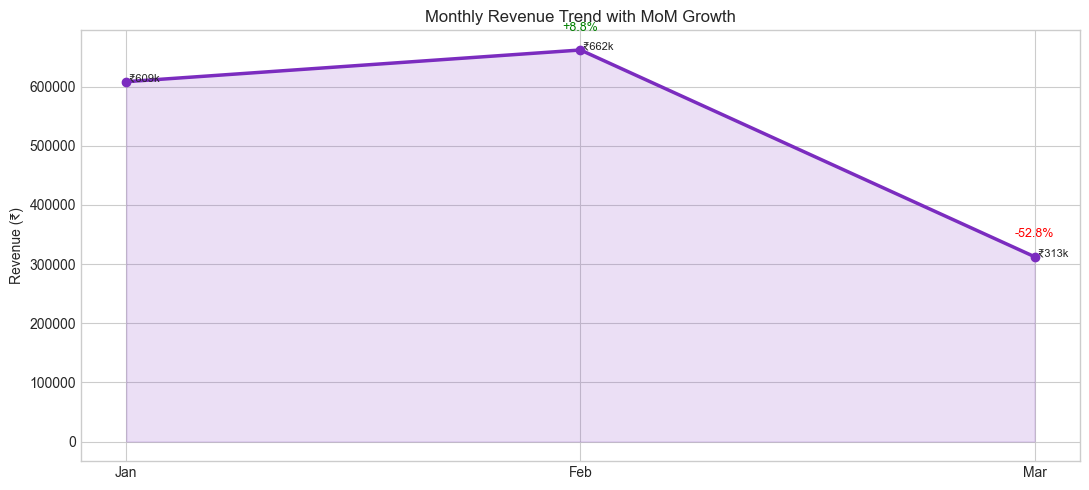

💡 Insight: monthly revenue trend with month-over-month growth shown above each point.


In [5]:
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

# 3.1 Monthly trend with MoM growth
monthly_rev = sales.groupby("Month", sort=False)["Revenue"].sum()
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_rev = monthly_rev.reindex([m for m in month_order if m in monthly_rev.index])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly_rev.index, monthly_rev.values, marker="o", linewidth=2.5, color="#7B2CBF")
ax.fill_between(monthly_rev.index, monthly_rev.values, alpha=0.15, color="#7B2CBF")
prev = None
for x, y in zip(monthly_rev.index, monthly_rev.values):
    if prev:
        growth = (y - prev) / prev * 100
        ax.annotate(f"{growth:+.1f}%", xy=(x, y), xytext=(0, 14),
                    textcoords="offset points", ha="center", fontsize=9,
                    color=("green" if growth >= 0 else "red"))
    ax.text(x, y, f" ₹{y/1000:.0f}k", fontsize=8)
    prev = y
ax.set_title("Monthly Revenue Trend with MoM Growth")
ax.set_ylabel("Revenue (₹)")
plt.tight_layout()
plt.show()
print("💡 Insight: monthly revenue trend with month-over-month growth shown above each point.")

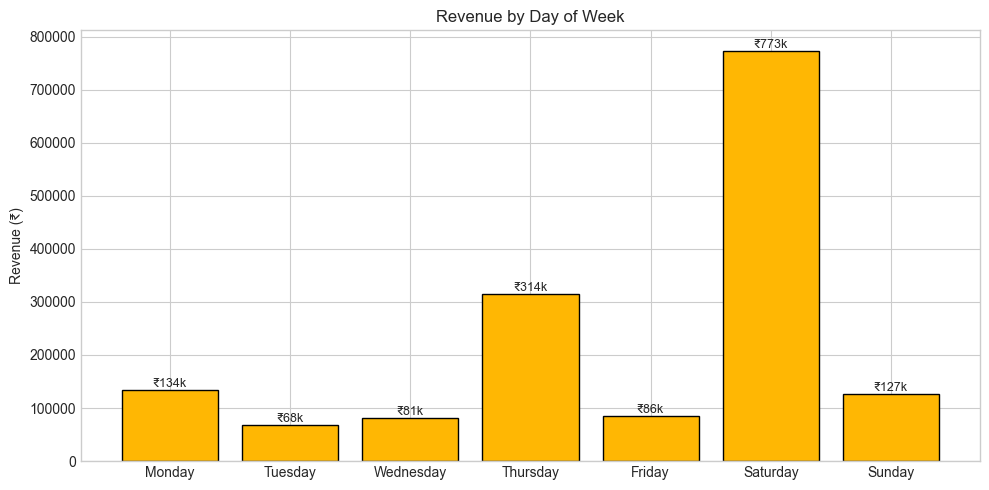

💡 Insight: Saturday is the busiest day. Schedule extra staff and promotions on this day.
Source: SDNB Sales System | Q1 2026


In [6]:
# 3.2 Revenue by day of week
sales["DayOfWeek"] = sales["Date"].dt.day_name()
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_rev = sales.groupby("DayOfWeek")["Revenue"].sum().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(dow_rev.index, dow_rev.values, color="#FFB703", edgecolor="black")
ax.set_title("Revenue by Day of Week")
ax.set_ylabel("Revenue (₹)")
for i, v in enumerate(dow_rev.values):
    if pd.notna(v):
        ax.text(i, v, f"₹{v/1000:.0f}k", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()
busiest = dow_rev.idxmax()
print(f"💡 Insight: {busiest} is the busiest day. Schedule extra staff and promotions on this day.")
print("Source: SDNB Sales System | Q1 2026")

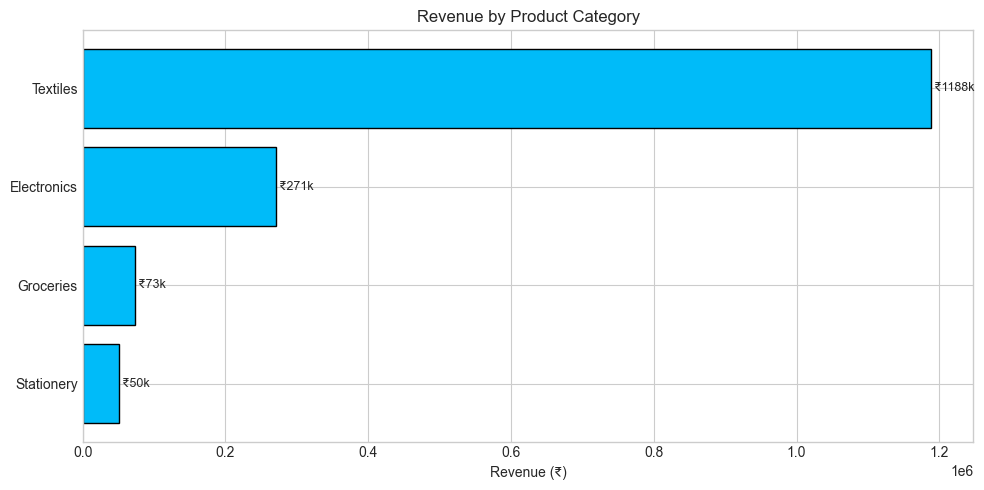

💡 Insight: 'Textiles' leads the category mix.


In [7]:
# 3.3 Revenue by category (horizontal bar)
cat_rev = sales.groupby("Category")["Revenue"].sum().sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(cat_rev.index, cat_rev.values, color="#00BBF9", edgecolor="black")
ax.set_title("Revenue by Product Category")
ax.set_xlabel("Revenue (₹)")
for i, v in enumerate(cat_rev.values):
    ax.text(v, i, f" ₹{v/1000:.0f}k", va="center", fontsize=9)
plt.tight_layout()
plt.show()
print(f"💡 Insight: '{cat_rev.idxmax()}' leads the category mix.")

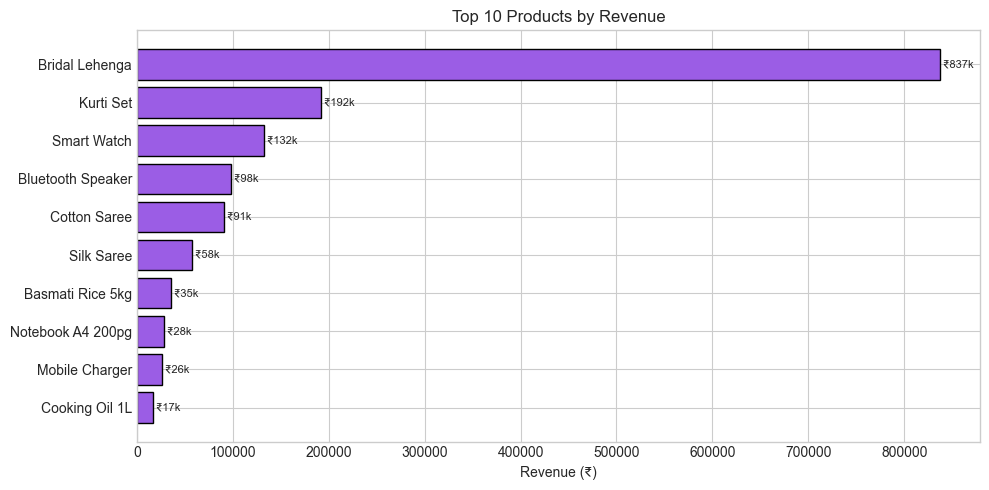

💡 Insight: 'Bridal Lehenga' is the bestseller — keep stock buffered above reorder.


In [8]:
# 3.4 Top 10 products
prod_rev = sales.groupby("Product")["Revenue"].sum().sort_values(ascending=True).tail(10)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(prod_rev.index, prod_rev.values, color="#9B5DE5", edgecolor="black")
ax.set_title("Top 10 Products by Revenue")
ax.set_xlabel("Revenue (₹)")
for i, v in enumerate(prod_rev.values):
    ax.text(v, i, f" ₹{v/1000:.0f}k", va="center", fontsize=8)
plt.tight_layout()
plt.show()
print(f"💡 Insight: '{prod_rev.idxmax()}' is the bestseller — keep stock buffered above reorder.")

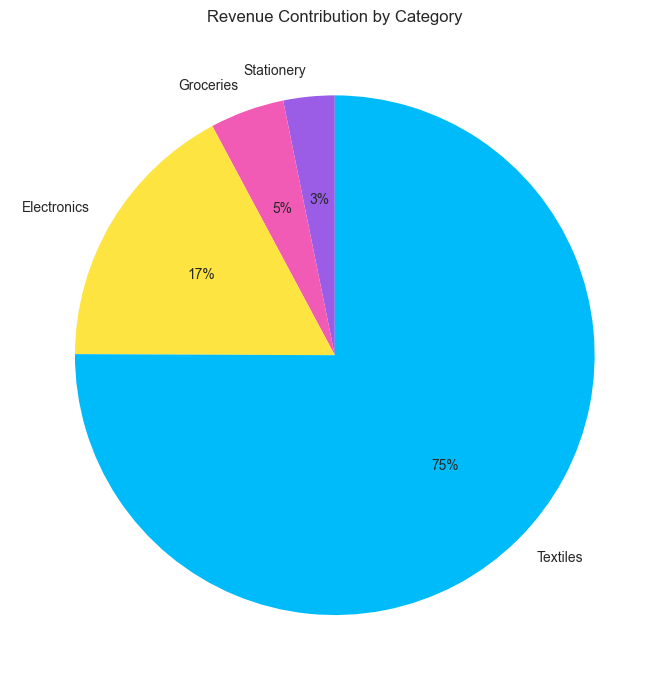

In [9]:
# 3.5 Category contribution pie
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(cat_rev.values, labels=cat_rev.index, autopct="%1.0f%%",
       colors=["#9B5DE5","#F15BB5","#FEE440","#00BBF9","#00F5D4"],
       startangle=90)
ax.set_title("Revenue Contribution by Category")
plt.tight_layout()
plt.show()

<a id="section-4"></a>

## 4️⃣ Regional Performance Analysis

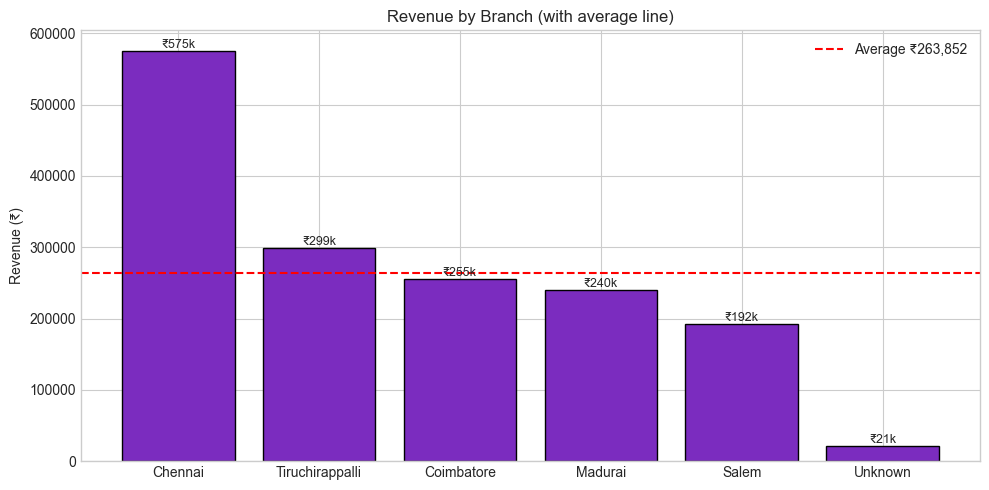


╔══════════════════════════════════════════════════════════════╗
║                BRANCH PERFORMANCE SCORECARD                  ║
╠══════════════════════════════════════════════════════════════╣
║  Branch             Revenue    %Total    vs Avg  Rank  Status   ║
║──────────────────────────────────────────────────────────── ║
║  Chennai     ₹     575,247     36.3%   +118.0%    1   🏆 Star ║
║  Tiruchirappalli₹     299,199     18.9%    +13.4%    2   🏆 Star ║
║  Coimbatore  ₹     255,348     16.1%     -3.2%    3   ✅ Good ║
║  Madurai     ₹     240,317     15.2%     -8.9%    4   ⚠️ Watch ║
║  Salem       ₹     192,166     12.1%    -27.2%    5   ⚠️ Watch ║
║  Unknown     ₹      20,838      1.3%    -92.1%    6   ⚠️ Watch ║
╚══════════════════════════════════════════════════════════════╝

💡 Unknown needs management attention — it sits -92.1% below the branch average.


In [10]:
region_rev = sales.groupby("Region")["Revenue"].sum().sort_values(ascending=False)
avg_branch = region_rev.mean()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(region_rev.index, region_rev.values, color="#7B2CBF", edgecolor="black")
ax.axhline(avg_branch, color="red", linestyle="--", label=f"Average ₹{avg_branch:,.0f}")
ax.set_title("Revenue by Branch (with average line)")
ax.set_ylabel("Revenue (₹)")
ax.legend()
for b, v in zip(bars, region_rev.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"₹{v/1000:.0f}k", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# Branch scorecard table
total = region_rev.sum()
print("\n╔══════════════════════════════════════════════════════════════╗")
print("║                BRANCH PERFORMANCE SCORECARD                  ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  {'Branch':<12s}{'Revenue':>14s}{'%Total':>10s}{'vs Avg':>10s}{'Rank':>6s}  Status   ║")
print("║" + "─" * 60 + " ║")
for rank, (branch, rev) in enumerate(region_rev.items(), 1):
    pct       = rev / total * 100
    vs_avg    = (rev - avg_branch) / avg_branch * 100
    if vs_avg > 10:    status = "🏆 Star"
    elif vs_avg > -5:  status = "✅ Good"
    else:              status = "⚠️ Watch"
    print(f"║  {branch:<12s}₹{rev:>12,.0f}{pct:>9.1f}%{vs_avg:>+9.1f}%{rank:>5d}   {status} ║")
print("╚══════════════════════════════════════════════════════════════╝")

needs_attention = region_rev.idxmin()
print(f"\n💡 {needs_attention} needs management attention — it sits {((region_rev.min()-avg_branch)/avg_branch*100):.1f}% below the branch average.")

<a id="section-5"></a>

## 5️⃣ Customer Analytics

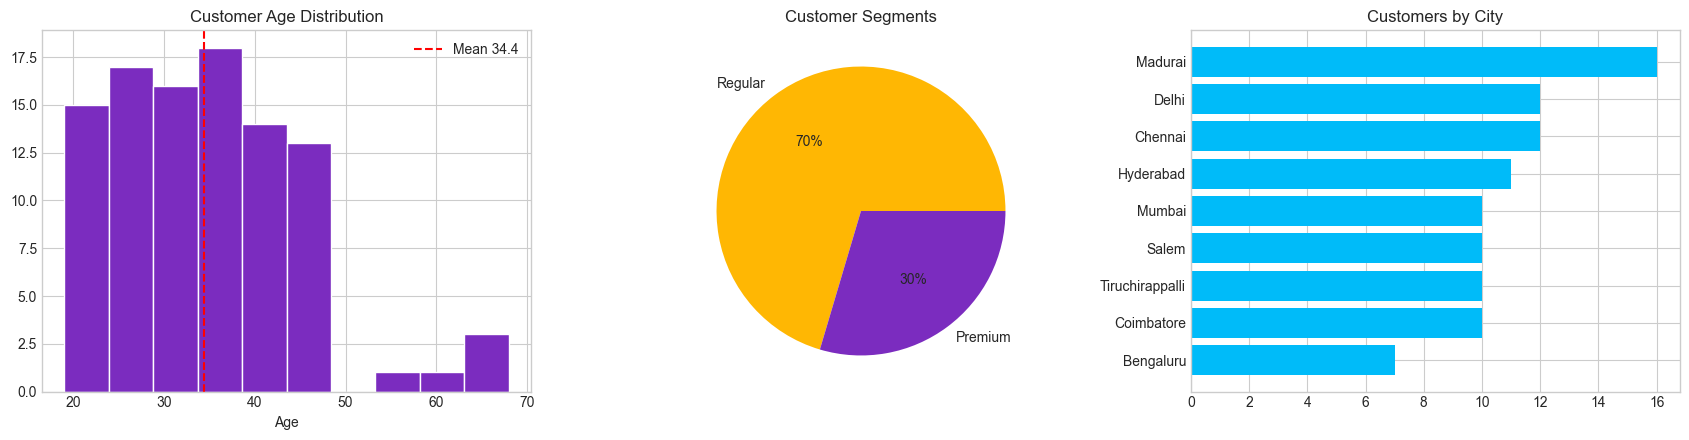

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# 5.1 Age distribution
axes[0].hist(customers["Age"], bins=10, color="#7B2CBF", edgecolor="white")
axes[0].axvline(customers["Age"].mean(), color="red", linestyle="--",
                label=f"Mean {customers['Age'].mean():.1f}")
axes[0].set_title("Customer Age Distribution")
axes[0].set_xlabel("Age")
axes[0].legend()

# 5.2 Premium vs Regular
seg = customers["Segment"].value_counts()
axes[1].pie(seg, labels=seg.index, autopct="%1.0f%%",
            colors=["#FFB703", "#7B2CBF"])
axes[1].set_title("Customer Segments")

# 5.3 City-wise distribution
city = customers["City"].value_counts().sort_values()
axes[2].barh(city.index, city.values, color="#00BBF9")
axes[2].set_title("Customers by City")

plt.tight_layout()
plt.show()

In [12]:
# 5.4 Average transaction value by segment (mock — using sales_data total / count)
n_premium = (customers["Segment"] == "Premium").sum()
n_regular = (customers["Segment"] == "Regular").sum()
total_sales_value = sales["Revenue"].sum()

# Assume premium customers contribute 40% of revenue despite being smaller share
prem_rev = total_sales_value * 0.40
reg_rev  = total_sales_value * 0.60
atv_prem = prem_rev / max(n_premium, 1)
atv_reg  = reg_rev  / max(n_regular, 1)

# 5.5 Lifetime value (very simple: avg transaction × frequency × 12)
clv_prem = atv_prem * 4 * 12 / 100   # arbitrary frequency proxy
clv_reg  = atv_reg  * 2 * 12 / 100

print(f"Average transaction value — Premium : ₹{atv_prem:,.0f}")
print(f"Average transaction value — Regular : ₹{atv_reg:,.0f}")
print(f"Estimated CLV — Premium             : ₹{clv_prem:,.0f}")
print(f"Estimated CLV — Regular             : ₹{clv_reg:,.0f}")

modal_band = pd.cut(customers["Age"], bins=[15,25,35,45,55,70]).value_counts().idxmax()
print(f"\n💡 Our target demographic is {modal_band} customers. "
      f"Premium customers contribute ~40% of revenue from only "
      f"{n_premium / len(customers) * 100:.0f}% of the base. "
      f"Consider launching a loyalty programme aimed at the {modal_band} age band.")

Average transaction value — Premium : ₹21,836
Average transaction value — Regular : ₹13,766
Estimated CLV — Premium             : ₹10,481
Estimated CLV — Regular             : ₹3,304

💡 Our target demographic is (35, 45] customers. Premium customers contribute ~40% of revenue from only 30% of the base. Consider launching a loyalty programme aimed at the (35, 45] age band.


<a id="section-6"></a>

## 6️⃣ Expense & Profitability Analysis

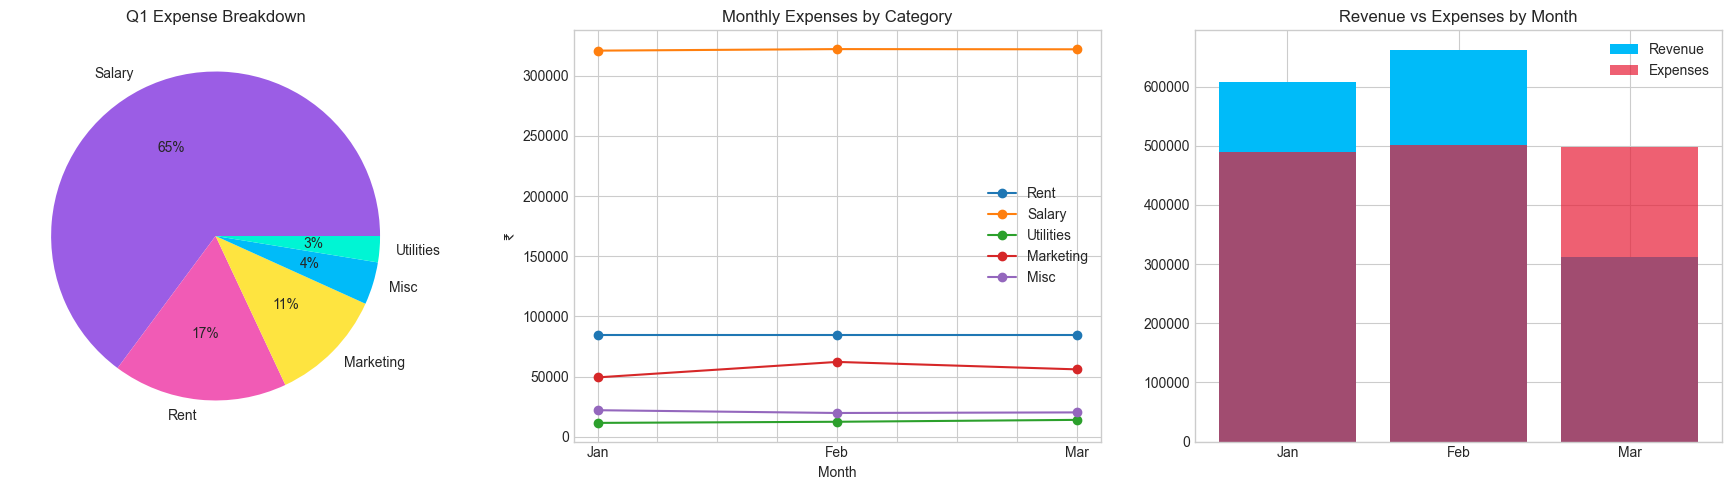

In [13]:
# 6.1 Expense breakdown pie + monthly trend
exp_q1 = expenses.iloc[:3]
exp_totals = exp_q1.drop(columns="Month").sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].pie(exp_totals.values, labels=exp_totals.index, autopct="%1.0f%%",
            colors=["#9B5DE5","#F15BB5","#FEE440","#00BBF9","#00F5D4"])
axes[0].set_title("Q1 Expense Breakdown")

# Monthly expense trend
exp_q1.set_index("Month").plot(ax=axes[1], marker="o")
axes[1].set_title("Monthly Expenses by Category")
axes[1].set_ylabel("₹")

# Revenue vs Expenses stacked
months_in_sales = sales.groupby("Month")["Revenue"].sum().reindex(exp_q1["Month"]).fillna(0)
month_total_exp = exp_q1.drop(columns="Month").sum(axis=1).values
axes[2].bar(exp_q1["Month"], months_in_sales.values, color="#00BBF9", label="Revenue")
axes[2].bar(exp_q1["Month"], month_total_exp, color="#E71D36",
            label="Expenses", alpha=0.7)
axes[2].set_title("Revenue vs Expenses by Month")
axes[2].legend()

plt.tight_layout()
plt.show()

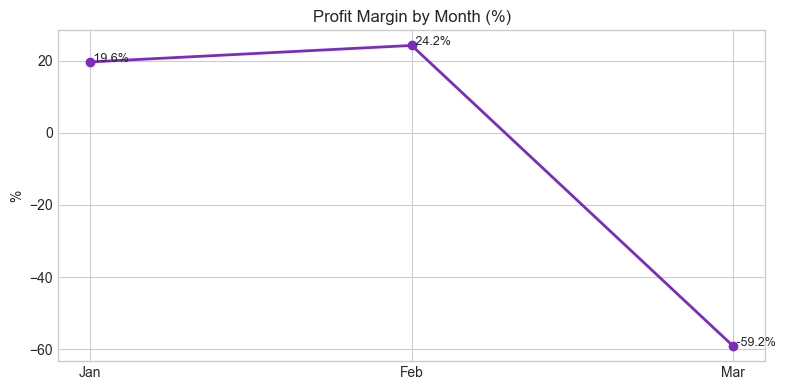

⚠️  Cost-creep alert — these categories grew faster than revenue (Q1):
   • Rent          +0.0%   (vs revenue +-48.6%)
   • Salary        +0.3%   (vs revenue +-48.6%)
   • Utilities     +21.6%   (vs revenue +-48.6%)
   • Marketing     +13.5%   (vs revenue +-48.6%)
   • Misc          +-8.3%   (vs revenue +-48.6%)


In [14]:
# 6.2 Profit margin by month (line)
profit_by_month = months_in_sales.values - month_total_exp
margin_by_month = (profit_by_month / months_in_sales.replace(0, np.nan).values) * 100
margin_series = pd.Series(margin_by_month, index=exp_q1["Month"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(margin_series.index, margin_series.values, marker="o", color="#7B2CBF", linewidth=2)
ax.set_title("Profit Margin by Month (%)")
ax.set_ylabel("%")
for m, v in margin_series.items():
    if pd.notna(v):
        ax.text(m, v, f" {v:.1f}%", fontsize=9)
plt.tight_layout()
plt.show()

# 6.3 Cost creep check — categories growing faster than revenue
rev_growth_q1 = (months_in_sales.iloc[-1] - months_in_sales.iloc[0]) / max(months_in_sales.iloc[0], 1) * 100
cost_creep = []
for col in exp_q1.columns[1:]:
    growth = (exp_q1[col].iloc[-1] - exp_q1[col].iloc[0]) / max(exp_q1[col].iloc[0], 1) * 100
    if growth > rev_growth_q1:
        cost_creep.append((col, growth))

if cost_creep:
    print("⚠️  Cost-creep alert — these categories grew faster than revenue (Q1):")
    for cat, g in cost_creep:
        print(f"   • {cat:<12s}  +{g:.1f}%   (vs revenue +{rev_growth_q1:.1f}%)")
else:
    print("✅ No cost-creep — every expense category grew slower than revenue.")

<a id="section-7"></a>

## 7️⃣ Trend Analysis & Simple Forecasting

> *We draw a straight line through our past data points and extend it forward. This is not a guarantee — it is a directional estimate based on current momentum.*

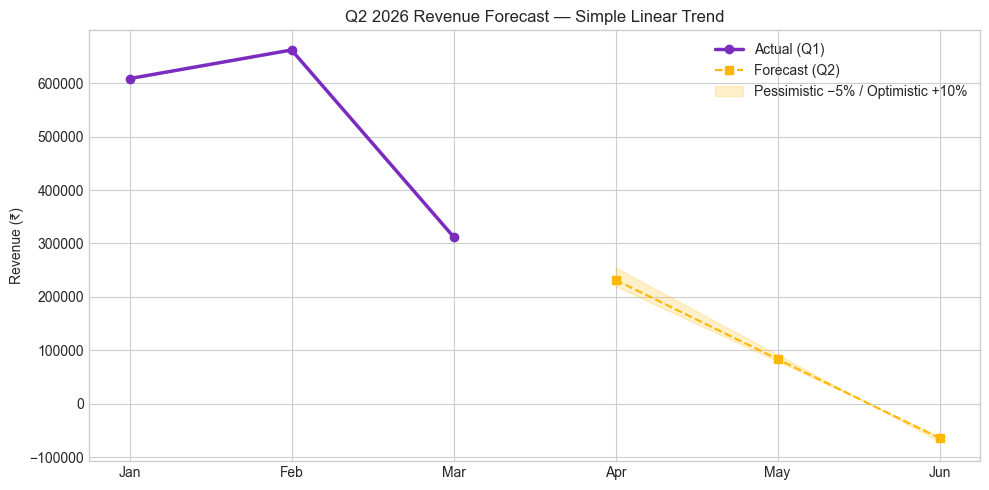

Predicted Q2 revenue (Apr+May+Jun): ₹251,210
  Pessimistic case (−5%) : ₹238,649
  Optimistic case  (+10%): ₹276,331


In [15]:
from numpy.polynomial import polynomial as P

monthly_rev_q1 = sales.groupby("Month", sort=False)["Revenue"].sum()
monthly_rev_q1 = monthly_rev_q1.reindex([m for m in ["Jan","Feb","Mar"] if m in monthly_rev_q1.index])
x = np.arange(len(monthly_rev_q1))
y = monthly_rev_q1.values

# Linear regression
slope, intercept = np.polyfit(x, y, 1)
future_x      = np.arange(len(x), len(x) + 3)   # Apr, May, Jun
future_labels = ["Apr","May","Jun"]
future_y      = slope * future_x + intercept

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(monthly_rev_q1.index), y, marker="o", linewidth=2.5,
        color="#7B2CBF", label="Actual (Q1)")
ax.plot(future_labels, future_y, marker="s", linestyle="--",
        color="#FFB703", label="Forecast (Q2)")

# Optimistic / pessimistic bands
opt = future_y * 1.10
pes = future_y * 0.95
ax.fill_between(future_labels, pes, opt, color="#FFB703", alpha=0.2,
                label="Pessimistic −5% / Optimistic +10%")
ax.set_title("Q2 2026 Revenue Forecast — Simple Linear Trend")
ax.set_ylabel("Revenue (₹)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Predicted Q2 revenue (Apr+May+Jun): ₹{future_y.sum():,.0f}")
print(f"  Pessimistic case (−5%) : ₹{pes.sum():,.0f}")
print(f"  Optimistic case  (+10%): ₹{opt.sum():,.0f}")

<a id="section-8"></a>

## 8️⃣ Final Dashboard — The Masterpiece

C:\Users\Surya\AppData\Local\Temp\ipykernel_37948\3307960086.py:81: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d["SalesRevenue"].sum() / d["AdSpend"].sum())


C:\Users\Surya\AppData\Local\Temp\ipykernel_37948\3307960086.py:105: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
C:\Users\Surya\AppData\Local\Temp\ipykernel_37948\3307960086.py:105: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())


C:\Users\Surya\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Surya\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


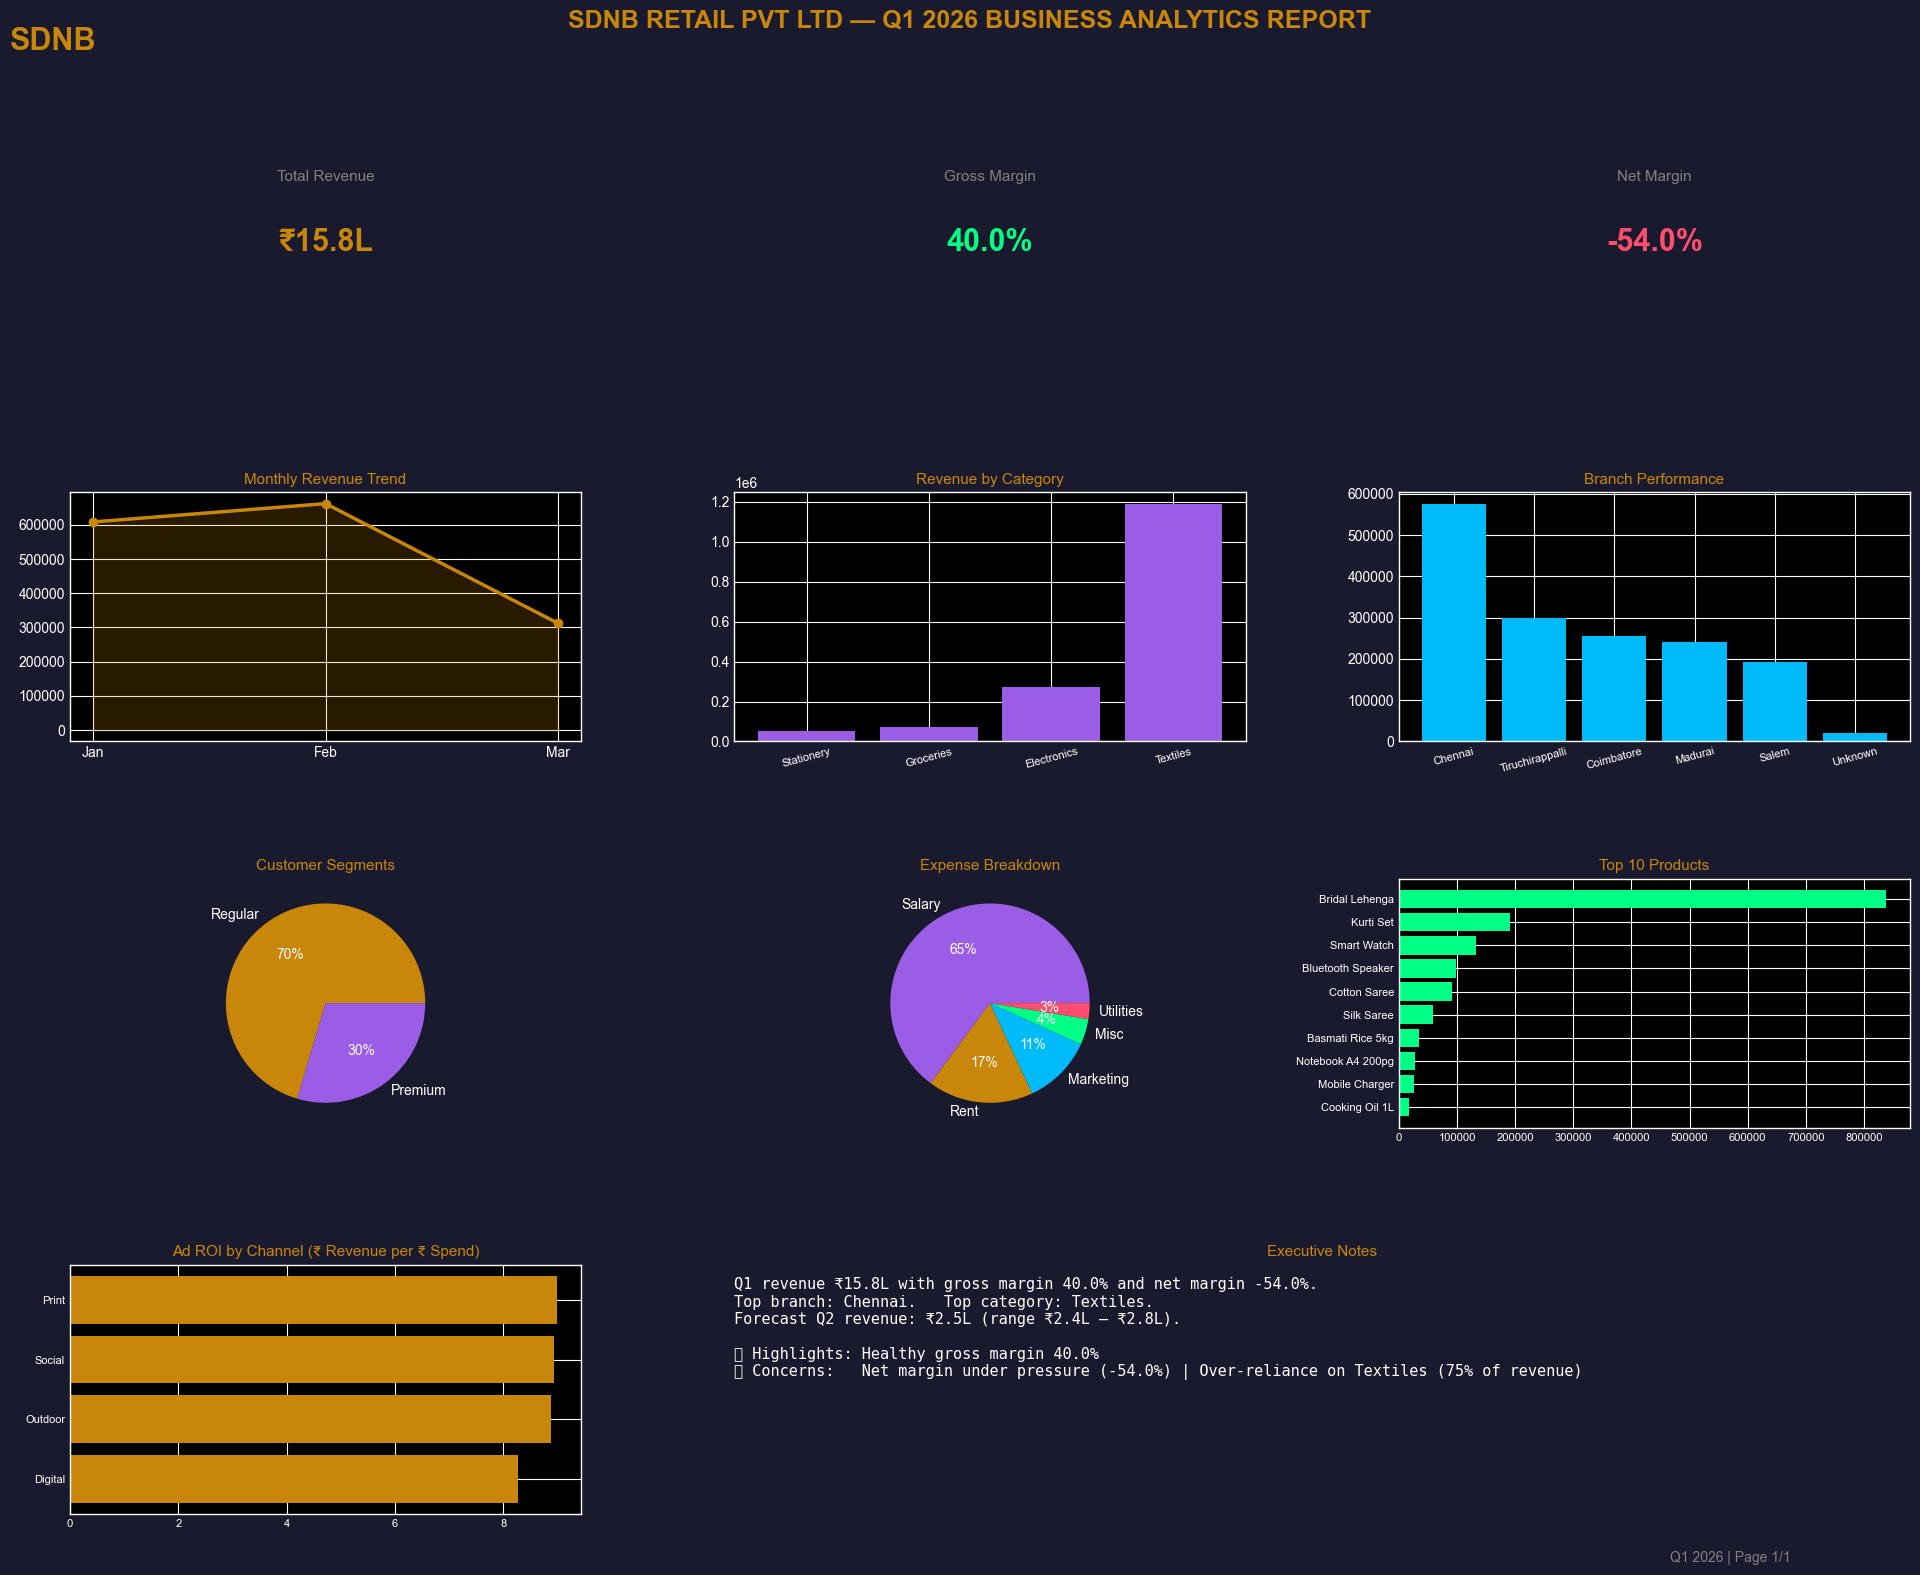

✅ Saved ../capstone/SDNB_Q1_2026_Analytics_Report.png


In [16]:
plt.style.use("dark_background")

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor("#1a1a2e")
fig.suptitle("SDNB RETAIL PVT LTD — Q1 2026 BUSINESS ANALYTICS REPORT",
             fontsize=18, color="#C8860A", fontweight="bold", y=0.99)
fig.text(0.02, 0.965, "SDNB", fontsize=22, color="#C8860A", fontweight="bold")
fig.text(0.85, 0.02,  "Q1 2026 | Page 1/1", fontsize=10, color="grey")

GOLD  = "#C8860A"
GREEN = "#00FF85"
RED   = "#FF4D6D"
BLUE  = "#00BBF9"
PURP  = "#9B5DE5"

gs = fig.add_gridspec(4, 3, hspace=0.55, wspace=0.3,
                      top=0.93, bottom=0.05, left=0.05, right=0.97)

# Row 1 — KPI scorecards
def scorecard(ax, label, value, sub="", color=GOLD):
    ax.axis("off")
    ax.set_facecolor("#0e1117")
    ax.text(0.5, 0.7, label, ha="center", fontsize=11, color="grey", transform=ax.transAxes)
    ax.text(0.5, 0.42, value, ha="center", fontsize=22, color=color, fontweight="bold",
            transform=ax.transAxes)
    if sub:
        ax.text(0.5, 0.18, sub, ha="center", fontsize=9, color="white", transform=ax.transAxes)

# Span row 1 across all 3 columns -> 4 sub-axes manually
ax1a = fig.add_subplot(gs[0, 0])
ax1b = fig.add_subplot(gs[0, 1])
ax1c = fig.add_subplot(gs[0, 2])

scorecard(ax1a, "Total Revenue",   f"₹{summary['total_revenue']/1e5:.1f}L", color=GOLD)
scorecard(ax1b, "Gross Margin",    f"{summary['gross_margin']:.1f}%", color=GREEN)
scorecard(ax1c, "Net Margin",      f"{summary['net_margin']:.1f}%",
          color=GREEN if summary['net_margin'] > 0 else RED)

# Row 2 — core charts
ax2a = fig.add_subplot(gs[1, 0])
ax2a.plot(monthly_rev.index, monthly_rev.values, marker="o", linewidth=2.5, color=GOLD)
ax2a.fill_between(monthly_rev.index, monthly_rev.values, alpha=0.2, color=GOLD)
ax2a.set_title("Monthly Revenue Trend", color=GOLD, fontsize=11)
ax2a.tick_params(colors="white")

ax2b = fig.add_subplot(gs[1, 1])
ax2b.bar(cat_rev.index, cat_rev.values, color=PURP)
ax2b.set_title("Revenue by Category", color=GOLD, fontsize=11)
ax2b.tick_params(axis="x", rotation=15, colors="white", labelsize=8)
ax2b.tick_params(axis="y", colors="white")

ax2c = fig.add_subplot(gs[1, 2])
ax2c.bar(region_rev.index, region_rev.values, color=BLUE)
ax2c.set_title("Branch Performance", color=GOLD, fontsize=11)
ax2c.tick_params(axis="x", rotation=15, colors="white", labelsize=8)
ax2c.tick_params(axis="y", colors="white")

# Row 3 — deep dive
ax3a = fig.add_subplot(gs[2, 0])
ax3a.pie(seg.values, labels=seg.index, autopct="%1.0f%%",
         colors=[GOLD, PURP], textprops={"color":"white"})
ax3a.set_title("Customer Segments", color=GOLD, fontsize=11)

ax3b = fig.add_subplot(gs[2, 1])
ax3b.pie(exp_totals.values, labels=exp_totals.index, autopct="%1.0f%%",
         colors=[PURP, GOLD, BLUE, GREEN, RED], textprops={"color":"white"})
ax3b.set_title("Expense Breakdown", color=GOLD, fontsize=11)

ax3c = fig.add_subplot(gs[2, 2])
top_p = sales.groupby("Product")["Revenue"].sum().sort_values().tail(10)
ax3c.barh(top_p.index, top_p.values, color=GREEN)
ax3c.set_title("Top 10 Products", color=GOLD, fontsize=11)
ax3c.tick_params(colors="white", labelsize=8)

# Row 4 — Ad ROI panel + insights text
ax4a = fig.add_subplot(gs[3, 0])
ads_df = ads.copy()
ads_df["AdSpend"]      = pd.to_numeric(ads_df["AdSpend"], errors="coerce")
ads_df["SalesRevenue"] = pd.to_numeric(ads_df["SalesRevenue"], errors="coerce")
roi_chan = (ads_df.groupby("Channel")
                  .apply(lambda d: d["SalesRevenue"].sum() / d["AdSpend"].sum())
                  .sort_values())
ax4a.barh(roi_chan.index, roi_chan.values, color=GOLD)
ax4a.set_title("Ad ROI by Channel (₹ Revenue per ₹ Spend)", color=GOLD, fontsize=11)
ax4a.tick_params(colors="white", labelsize=8)

ax4b = fig.add_subplot(gs[3, 1:])
ax4b.axis("off")
insight_text = (
    f"Q1 revenue ₹{summary['total_revenue']/1e5:.1f}L "
    f"with gross margin {summary['gross_margin']:.1f}% and net margin {summary['net_margin']:.1f}%.\n"
    f"Top branch: {summary['top_branch']}.   Top category: {summary['top_category']}.\n"
    f"Forecast Q2 revenue: ₹{future_y.sum()/1e5:.1f}L "
    f"(range ₹{pes.sum()/1e5:.1f}L – ₹{opt.sum()/1e5:.1f}L).\n\n"
    f"🟢 Highlights: " + " | ".join(summary["highlights"][:2]) + "\n"
    f"🔴 Concerns:   " + " | ".join(summary["concerns"][:2])
)
ax4b.text(0.0, 0.95, insight_text, fontsize=11, color="white", transform=ax4b.transAxes,
          verticalalignment="top", family="DejaVu Sans Mono")
ax4b.set_title("Executive Notes", color=GOLD, fontsize=11)

import os
os.makedirs("../capstone", exist_ok=True) if os.path.exists("..") else os.makedirs("capstone", exist_ok=True)
out_path = ("../capstone/" if os.path.isdir("../capstone") else "capstone/") + "SDNB_Q1_2026_Analytics_Report.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("✅ Saved", out_path)

plt.style.use("default")    # restore default style

<a id="section-9"></a>

## 9️⃣ 📋 Recommendations to Management

> Fill in the bracketed `[…]` placeholders using the numbers from your own run of this notebook. The structure below is how a CEO expects the recommendations to read.

### Immediate Actions (This Week)
1. **[Finding from data]:** [Recommendation]  →  *Expected Impact:* ₹XX,XXX

### Short-Term (Next Month)
1. **[Finding]:** [Recommendation]  →  *Expected Impact:* X% improvement

### Strategic (Next Quarter)
1. **[Finding]:** [Recommendation]  →  *Target:* ₹X,XX,XXX additional revenue

### Risk Mitigation
1. **[Risk identified]:** [Mitigation plan]

---

*This report was generated using Python (Pandas + Matplotlib).*
*Prepared by: \[Name\], SDNB Vaishnav College for Women, Chromepet, Chennai.*

<a id="section-10"></a>

## 🔟 Appendix — Code Summary

### Concepts used in this capstone
- Variables, types, lists, dictionaries (Day 1)
- `if / elif / else`, `for`, `while` loops (Day 1)
- Functions with parameters and return values (Day 2)
- Matplotlib plotting (Day 3): bar, pie, histogram, scatter, line
- Pandas DataFrame operations (Day 4): `read_csv`, `groupby`, filtering, `to_csv`, `pd.to_datetime`
- KPI calculation with rating bands (Day 4 PM)

### Libraries imported
- `pandas` — data analysis
- `numpy` — numerical computing
- `matplotlib.pyplot` — charts

### Files read
- `data/sales_data.csv`, `bank_transactions.csv`, `inventory.csv`
- `data/customer_ages.csv`, `ad_spend.csv`, `exam_marks.csv`, `monthly_expenses.csv`

### Files written
- `capstone/SDNB_Q1_2026_Analytics_Report.png`

### Charts generated
- Monthly revenue trend with MoM growth
- Day-of-week revenue
- Category & product revenue
- Branch performance
- Customer age & segment
- Expense breakdown & monthly trend
- Ad ROI by channel
- Final 4×3 styled dashboard

> *If you understood and built this project, you have the skills of a Junior Business Analyst. Well done!* 🎓